In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import plotly.graph_objects as go


/bin/bash: line 1: /home/nkemah/providers/Documents/ROAD: No such file or directory


# EDA

In [2]:
DATA = '../data/VDS2526_Madrid'

# Load station metadata
stations = pd.read_csv(f'{DATA}/stations.csv')

# Load and combine all yearly measurement files
all_files = sorted(glob.glob(f'{DATA}/madrid_*.csv'))
measurements = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

# Parse date and extract time components
measurements['date'] = pd.to_datetime(measurements['date'])
measurements['year'] = measurements['date'].dt.year
measurements['month'] = measurements['date'].dt.month
measurements['hour'] = measurements['date'].dt.hour

# Merge station metadata into measurements
measurements = measurements.merge(stations, left_on='station', right_on='id', how='left')

print(f"Total rows: {measurements.shape[0]}")
print(f"Columns: {measurements.columns.tolist()}")

Total rows: 3808224
Columns: ['date', 'BEN', 'CO', 'EBE', 'MXY', 'NMHC', 'NO_2', 'NOx', 'OXY', 'O_3', 'PM10', 'PXY', 'SO_2', 'TCH', 'TOL', 'station', 'PM25', 'NO', 'CH4', 'year', 'month', 'hour', 'id', 'name', 'address', 'lon', 'lat', 'elevation']


In [3]:
measurements.head()

,date,BEN,CO,EBE,MXY,NMHC,NO_2,NOx,OXY,O_3,...,CH4,year,month,hour,id,name,address,lon,lat,elevation
0,2001-08-01 01:00:00,NaN,0.37,NaN,NaN,NaN,58.400002,87.150002,NaN,34.529999,...,NaN,2001,8,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2001-08-01 01:00:00,1.5,0.34,1.49,4.1,0.07,56.250000,75.169998,2.11,42.160000,...,NaN,2001,8,1,28079035.0,Pza. del Carmen,Plaza del Carmen esq. Tres Cruces.,-3.703172,40.419208,659.0
2,2001-08-01 01:00:00,NaN,0.28,NaN,NaN,NaN,50.660000,61.380001,NaN,46.310001,...,NaN,2001,8,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-08-01 01:00:00,NaN,0.47,NaN,NaN,NaN,69.790001,73.449997,NaN,40.650002,...,NaN,2001,8,1,28079004.0,Pza. de España,Plaza de España,-3.712247,40.423853,635.0
4,2001-08-01 01:00:00,NaN,0.39,NaN,NaN,NaN,22.830000,24.799999,NaN,66.309998,...,NaN,2001,8,1,28079039.0,Barrio del Pilar,Avd. Betanzos esq. C/ Monforte de Lemos,-3.711542,40.478228,674.0


In [4]:
#check amount of data across the years
print(measurements['year'].value_counts().sort_index())

year
2001    217847
2002    217296
2003    243981
2004    245496
2005    237002
2006    230569
2007    225119
2008    226393
2009    215693
2010    209443
2011    209929
2012    210720
2013    209880
2014    210024
2015    210096
2016    209496
2017    210120
2018     69120
Name: count, dtype: int64


In [5]:
#exclude 2018 (only 3 months worth of data)
df_full = measurements[measurements['year'] <= 2017]

In [6]:
# Missing values as percentages
ALL_POLLUTANTS = ['BEN', 'CO', 'EBE', 'MXY', 'NMHC', 'NO_2', 'NOx',
                  'OXY', 'O_3', 'PM10', 'PXY', 'SO_2', 'TCH', 'TOL',
                  'PM25', 'NO', 'CH4']

missing = (df_full[ALL_POLLUTANTS].isnull().sum() / len(df_full) * 100).round(1)
print(missing.sort_values())

NO_2     0.6
O_3     21.1
PM10    24.5
SO_2    26.5
CO      29.9
NOx     38.3
NO      60.9
NMHC    71.2
TCH     71.2
BEN     72.6
TOL     72.7
EBE     73.7
PM25    78.7
MXY     91.6
OXY     91.6
PXY     91.6
CH4     99.8
dtype: float64


In [7]:
# KEY_POLLUTANTS
# Select only pollutants with at least 70% data availability
THRESHOLD = 70
KEY_POLLUTANTS = missing[missing <= 30].index.tolist()

# Reorder to preferred order
PREFERRED_ORDER = ['NO_2', 'O_3', 'PM10', 'SO_2', 'CO']
KEY_POLLUTANTS = [p for p in PREFERRED_ORDER if p in KEY_POLLUTANTS]

print(f"Pollutants with >= {THRESHOLD}% availability:")
print(KEY_POLLUTANTS)

stats = df_full[KEY_POLLUTANTS].describe().round(2)
print(stats)

Pollutants with >= 70% availability:
['NO_2', 'O_3', 'PM10', 'SO_2', 'CO']
             NO_2         O_3        PM10        SO_2          CO
count  3718200.00  2951669.00  2824332.00  2747364.00  2622404.00
mean        50.69       39.76       29.14       10.71        0.55
std         34.62       30.41       26.02        9.14        0.54
min          0.00        0.00        0.00        0.00        0.00
25%         24.00       12.65       11.75        5.90        0.26
50%         44.32       34.66       21.75        8.20        0.40
75%         69.90       59.74       38.00       12.36        0.65
max        628.60      236.00      695.00      199.10       18.04


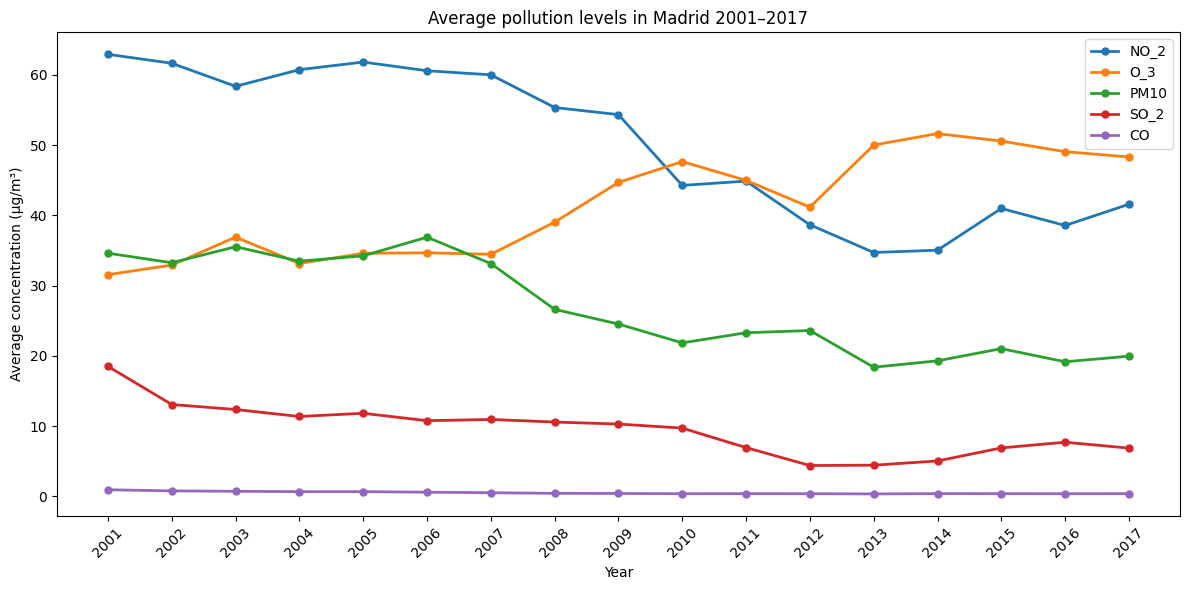

In [8]:
yearly_avg = df_full.groupby('year')[KEY_POLLUTANTS].mean()

fig, ax = plt.subplots(figsize=(12, 6))

for pollutant in KEY_POLLUTANTS:
    ax.plot(yearly_avg.index, yearly_avg[pollutant],
            marker='o', linewidth=2, markersize=5, label=pollutant)

ax.set_xlabel('Year')
ax.set_ylabel('Average concentration (µg/m³)')
ax.set_title('Average pollution levels in Madrid 2001–2017')
ax.set_xticks(yearly_avg.index)
ax.set_xticklabels(yearly_avg.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


# Question 1

In [9]:
baseline = yearly_avg.loc[2001]
pct_change = ((yearly_avg - baseline) / baseline * 100).round(2)

print(pct_change)

       NO_2    O_3   PM10   SO_2     CO
year                                   
2001   0.00   0.00   0.00   0.00   0.00
2002  -2.03   4.33  -3.93 -29.38 -17.43
2003  -7.24  16.95   2.66 -33.21 -23.76
2004  -3.48   5.04  -3.29 -38.59 -29.00
2005  -1.75   9.64  -1.08 -36.13 -29.17
2006  -3.72   9.88   6.59 -41.83 -37.46
2007  -4.64   9.19  -4.26 -40.89 -46.03
2008 -12.04  23.71 -23.11 -42.88 -55.26
2009 -13.65  41.64 -29.15 -44.41 -57.27
2010 -29.66  51.03 -36.90 -47.54 -61.22
2011 -28.70  42.57 -32.73 -62.55 -60.07
2012 -38.58  30.46 -31.82 -76.35 -61.45
2013 -44.85  58.50 -46.92 -76.10 -64.31
2014 -44.33  63.67 -44.28 -72.85 -60.03
2015 -34.88  60.30 -39.27 -62.79 -60.19
2016 -38.74  55.51 -44.68 -58.42 -61.47
2017 -33.93  53.13 -42.37 -62.95 -60.49


In [19]:
# Reset index to make year a column
pct_change_reset = pct_change.reset_index()

# Melt to long format for plotly
pct_change_long = pct_change_reset.melt(id_vars='year', var_name='pollutant', value_name='pct_change')

# Single style map for both lines and annotations
style_map = {
    'O_3': dict(color='#e63946', width=1.5),
    'NO_2': dict(color='#222222', width=1.5),
    'PM10': dict(color='#222222', width=1.5),
    'SO_2': dict(color='#222222', width=1.5),
    'CO':   dict(color='#222222', width=1.5)
}

opacity_map = {
    'O_3': 1.0,
    'NO_2': 0.8,
    'PM10': 0.8,
    'SO_2': 0.8,
    'CO':   0.8
}

fig1 = go.Figure()

#pollutant_order
pollutant_order = ['O_3', 'NO_2', 'PM10', 'SO_2', 'CO']

for pollutant in pollutant_order:
    df_line = pct_change_long[pct_change_long['pollutant'] == pollutant]
    
    fig1.add_trace(go.Scatter(
        x=df_line['year'],
        y=df_line['pct_change'],
        mode='lines+markers',
        name=pollutant,
        opacity=opacity_map[pollutant],
        line=style_map[pollutant],
        marker=dict(size=5),
        hovertemplate=(
            '<b>%{fullData.name}</b><br>' +
            'Year: %{x}<br>' +
            'Change: %{y:.1f}%<extra></extra>'
        )
    ))

# Reference line at y=0
fig1.add_hline(y=0, line_dash='dash', line_color='#adb5bd', line_width=1)

# Annotation arrow pointing to O3 divergence
fig1.add_annotation(
    x=2010,
    y=pct_change.loc[2010, 'O_3'],
    text='O₃ rising<br>while others fall',
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e63946',
    arrowwidth=2,
    ax=60,
    ay=-40,
    font=dict(color='#e63946', size=11),
    align='left'
)

# Manual y adjustments for overlapping labels
y_adjustments = {
    'O_3': 0,
    'NO_2': 0,
    'PM10': 0,
    'SO_2': -3,
    'CO':   3
}

# Add direct labels at 2017 endpoint
for pollutant in pollutant_order:
    last_val = pct_change.loc[2017, pollutant]
    fig1.add_annotation(
        x=2017,
        y=last_val + y_adjustments[pollutant],
        text=pollutant.replace('_', ''),
        xanchor='left',
        showarrow=False,
        font=dict(
            color=style_map[pollutant]['color'],
            size=12,
            family='Arial'
        ),
        xshift=5,
        opacity=min(opacity_map[pollutant] + 0.3, 1.0)
    )

fig1.update_layout(
    title=dict(
        text=(
            'Pollution levels in Madrid relative to 2001 baseline'
        ),
        font=dict(size=18)
    ),
    xaxis_title='Year',
    yaxis_title='Change relative to 2001 (%)',
    showlegend=False,
    hovermode='x unified',
    template='plotly_white',
    margin=dict(r=80),
    xaxis=dict(
    tickmode='array',
    tickvals=list(range(2001, 2018)),
    tickangle=0,
    showgrid=False,
    linecolor='black',
    linewidth=1,
    ticks='outside',
    ticklen=6,
    tickwidth=1,
    tickcolor='black',
    tickfont=dict(color='black')
),
yaxis=dict(
    tickmode='array',
    tickvals=list(range(-80, 81, 20)),
    range=[-85, 85],
    showgrid=True,
    gridcolor='#eeeeee',
    gridwidth=1,
    tickfont=dict(color='black')
)
)

fig1.show()

#save image
fig1.write_image("design1.png", width=1200, height=600, scale=3)

# Question 2

In [20]:
# Filter to 2017 only
df_2017 = df_full[df_full['year'] == 2017]

# Compute average O3 per station, drop stations with no O3 data
station_o3 = df_2017.groupby('name')['O_3'].mean().dropna().round(2)

# Rank from highest to lowest
station_o3 = station_o3.sort_values(ascending=False).reset_index()
station_o3.columns = ['station', 'avg_o3']

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=station_o3['avg_o3'],
    y=station_o3['station'],
    orientation='h',
    marker=dict(
        color=station_o3['avg_o3'],
        colorscale='Reds',
        showscale=False,
        colorbar=dict(
            title='O₃ (µg/m³)',
            tickfont=dict(color='black')
        )
    ),
    customdata=station_o3['avg_o3'],
    hovertemplate=(
        '<b>%{y}</b><br>' +
        'Average O₃: %{x:.2f} µg/m³<extra></extra>'
    )
))

fig2.add_vline(
    x=60,
    line_dash='dash',
    line_color='#222222',
    line_width=1.5,
    annotation_text='WHO guideline (60 µg/m³)',
    annotation_position='top',
    annotation_font=dict(color='#222222', size=11)
)

fig2.update_layout(
    title=dict(
        text=(
            'Average O₃ concentration by station in Madrid (2017)'
        ),
        font=dict(size=18)
    ),
    xaxis_title='Average O₃ concentration (µg/m³)',
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#cccccc',
        font=dict(color='black')
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor='#cccccc',
        gridwidth=1,
        linecolor='rgba(0,0,0,0)',
        tickfont=dict(color='black')
    ),
    yaxis=dict(
        autorange='reversed',
        linecolor='black',
        linewidth=1,
        tickfont=dict(color='black'),
        ticklabelstandoff=10
    ),
    template='plotly_white',
    margin=dict(r=100),
    height=700
)

fig2.show()

#save image
fig2.write_image("design2.png", width=1200, height=600, scale=3)

# Question 3

In [12]:
# Compute average O3 by month and hour
heatmap_data = df_full.groupby(['month', 'hour'])['O_3'].mean().round(2).reset_index()

print(heatmap_data)

     month  hour    O_3
0        1     0  17.60
1        1     1  19.32
2        1     2  20.44
3        1     3  21.62
4        1     4  22.58
..     ...   ...    ...
283     12    19  12.65
284     12    20  11.18
285     12    21  10.98
286     12    22  11.28
287     12    23  12.56

[288 rows x 3 columns]


In [21]:
# Pivot to matrix format - rows = hours, columns = months
heatmap_pivot = heatmap_data.pivot(index='hour', columns='month', values='O_3')

# Month names for x axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig3 = go.Figure()

fig3.add_trace(go.Heatmap(
    xgap=2,
    ygap=2,
    z=heatmap_pivot.values,
    x=month_names,
    y=list(range(24)),
    colorscale='Reds',

    hovertemplate=(
        'Month: %{x}<br>' +
        'Hour: %{y:02d}h<br>' +
        'Avg O₃: %{z:.2f} µg/m³<extra></extra>'
    ),
    colorbar=dict(
        title='O₃ (µg/m³)',
        tickfont=dict(color='black')
    )
))

fig3.update_layout(
    title=dict(
        text=(
            'Average O₃ concentration by hour and month in Madrid (2001–2017)'
        ),
        font=dict(size=18)
    ),
    xaxis_title='Month',
    yaxis_title='Hour of day',
    template='plotly_white',
    height=800,
    width=800,
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#cccccc',
        font=dict(color='black')
    ),
    xaxis=dict(
        tickfont=dict(color='black'),
        title_font=dict(color='black')
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(24)),
        ticktext=[f'{h:02d}h' for h in range(24)],
        autorange='reversed',
        tickfont=dict(color='black'),
        title_font=dict(color='black')
    )

)

fig3.show()

#save image
fig3.write_image("design3.png", width=1200, height=600, scale=3)